# Step 1: Represent the Data

In [74]:
# Each row: [acid_durability, strength, label]
training_data = [
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"]
]

# The new point we want to classify
new_point = [3, 7]

print(training_data[0])      # [7, 7, 'Bad']
print(training_data[0][2])   # 'Bad'
print(new_point)             # [3, 7]

[7, 7, 'Bad']
Bad
[3, 7]


# Step 2: Calculate Euclidean Distance

In [75]:
import math

def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total = total + (diff * diff)
    distance = math.sqrt(total)
    return distance

# Testing
print(euclidean_distance([3,7], [7,7]))  # 4.0
print(euclidean_distance([3,7], [7,4]))  # 5.0
print(euclidean_distance([3,7], [3,4]))  # 3.0
print(euclidean_distance([3,7], [1,4]))  # 3.605...
## Question: Which training point is closest to [3, 7]?
## 1,4 is closest to [3, 7]

4.0
5.0
3.0
3.605551275463989


# Step 3: Find K Nearest Neighbors

In [76]:
def get_neighbors(training_data, new_point, k):
    distances = []
    
    for row in training_data:
        features = [row[0], row[1]]
        label = row[2]
        dist = euclidean_distance(new_point, features)
        distances.append([dist, label])

    # Bubble sort
    for i in range(len(distances)):
        for j in range(i + 1, len(distances)):
            if distances[j][0] < distances[i][0]:
                temp = distances[i]
                distances[i] = distances[j]
                distances[j] = temp

    neighbors = []
    for i in range(k):
        neighbors.append(distances[i])

    return neighbors

# Test
neighbors = get_neighbors(training_data, [3,7], 3)
for n in neighbors:
    print("Distance:", round(n[0], 2), "Label:", n[1])

Distance: 3.0 Label: Good
Distance: 3.61 Label: Good
Distance: 4.0 Label: Bad


# Step 4: Vote and Classify

In [77]:
def classify(training_data, new_point, k):
    neighbors = get_neighbors(training_data, new_point, k)

    votes = {}
    for neighbor in neighbors:
        label = neighbor[1]
        if label in votes:
            votes[label] = votes[label] + 1
        else:
            votes[label] = 1

    best_label = None
    best_count = 0

    for label in votes:
        if votes[label] > best_count:
            best_count = votes[label]
            best_label = label

    return best_label

# Test
result = classify(training_data, [3, 7], 3)
print("Classification:", result)
# We had 2 Good neighbors and 1 Bad neighbor, so majority vote = Good.

Classification: Good


# Complete Knn Program

In [78]:
import math

# ---- Training Data ----
training_data = [
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"]
]

# ---- Functions ----
def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total = total + (diff * diff)
    return math.sqrt(total)


def get_neighbors(training_data, new_point, k):
    distances = []

    for row in training_data:
        features = [row[0], row[1]]
        label = row[2]
        dist = euclidean_distance(new_point, features)
        distances.append([dist, label])

    # Sort by distance (bubble sort)
    for i in range(len(distances)):
        for j in range(i + 1, len(distances)):
            if distances[j][0] < distances[i][0]:
                temp = distances[i]
                distances[i] = distances[j]
                distances[j] = temp

    neighbors = []
    for i in range(k):
        neighbors.append(distances[i])

    return neighbors


def classify(training_data, new_point, k):
    neighbors = get_neighbors(training_data, new_point, k)

    votes = {}
    for neighbor in neighbors:
        label = neighbor[1]
        if label in votes:
            votes[label] = votes[label] + 1
        else:
            votes[label] = 1

    best_label = None
    best_count = 0
    for label in votes:
        if votes[label] > best_count:
            best_count = votes[label]
            best_label = label

    return best_label


# ---- Classify a new point ----
new_point = [3, 7]
k = 3

result = classify(training_data, new_point, k)

print("New point:", new_point)
print("Using k =", k)
print("Classification:", result)

New point: [3, 7]
Using k = 3
Classification: Good


## Experiment & Explore

### Experiment 1: Effect of k

In [79]:
## When k = 1
new_point = [3, 7]
k = 1

result = classify(training_data, new_point, k)

print("New point:", new_point)
print("Using k =", k)
print("Classification:", result)

New point: [3, 7]
Using k = 1
Classification: Good


In [80]:
## when k = 3
new_point = [3, 7]
k = 3

result = classify(training_data, new_point, k)

print("New point:", new_point)
print("Using k =", k)
print("Classification:", result)

New point: [3, 7]
Using k = 3
Classification: Good


## Experiment 2: More Training Data

In [81]:
training_data = [
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"],
    [3, 6, "Good"],
    [5, 5, "Bad"],
    [2, 8, "Good"],
    [8, 3, "Bad"]
]
new_point = [3, 7]

for k in [3, 5]:
    result = classify(training_data, new_point, k)
    print(f"k = {k}, Classification = {result}")

k = 3, Classification = Good
k = 5, Classification = Good


## Experiment 3: Classify Multiple Points

In [83]:
test_points = [[5,6], [2,3], [8,8], [4,5]]

for point in test_points:
    result = classify(training_data, point, 3)
    print("Point:", point, "->", result)

Point: [5, 6] -> Bad
Point: [2, 3] -> Good
Point: [8, 8] -> Bad
Point: [4, 5] -> Good


# Task 1: Scratch KNN on the Iris Dataset

In [71]:
import math

# ---- Iris training data ----
training_data = [
    [5.1, 3.5, 1.4, 0.2, "Setosa"],
    [4.9, 3.0, 1.4, 0.2, "Setosa"],
    [5.0, 3.4, 1.5, 0.2, "Setosa"],
    [4.8, 3.1, 1.6, 0.2, "Setosa"],
    [7.0, 3.2, 4.7, 1.4, "Versicolor"],
    [6.4, 3.2, 4.5, 1.5, "Versicolor"],
    [5.5, 2.3, 4.0, 1.3, "Versicolor"],
    [6.5, 2.8, 4.6, 1.5, "Versicolor"],
    [6.3, 3.3, 6.0, 2.5, "Virginica"],
    [7.1, 3.0, 5.9, 2.1, "Virginica"],
    [6.5, 3.0, 5.8, 1.8, "Virginica"],
    [7.6, 3.0, 6.6, 2.1, "Virginica"]
]

# ---- Distance ----
def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total += diff * diff
    return math.sqrt(total)


# ---- Classifier ----
def classify(training_data, new_point, k):
    distances = []

    for row in training_data:
        features = row[:4]   # first 4 values
        label = row[4]
        dist = euclidean_distance(new_point, features)
        distances.append([dist, label])

    # sort by distance
    distances.sort()

    # get k neighbors
    neighbors = distances[:k]

    # voting
    votes = {}
    for _, label in neighbors:
        votes[label] = votes.get(label, 0) + 1

    # find best label
    best_label = None
    best_count = 0
    for label in votes:
        if votes[label] > best_count:
            best_count = votes[label]
            best_label = label

    return best_label


# ---- Test ----
test_flowers = [
    [5.0, 3.3, 1.4, 0.2],
    [6.0, 2.7, 4.5, 1.5],
    [7.2, 3.2, 6.0, 1.8]
]

for flower in test_flowers:
    result = classify(training_data, flower, 3)
    print("Flower:", flower, "-> Species:", result)

Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica


In [72]:
# Test with different k values 
test_flowers = [
    [5.0, 3.3, 1.4, 0.2],
    [6.0, 2.7, 4.5, 1.5],
    [7.2, 3.2, 6.0, 1.8]
]

k_values = [1, 3, 5]

for k in k_values:
    print("\nUsing k =", k)
    for flower in test_flowers:
        result = classify(training_data, flower, k)
        print("Flower:", flower, "-> Species:", result)


Using k = 1
Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica

Using k = 3
Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica

Using k = 5
Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica


### The results don’t change because each test flower is clearly closest to its own group,
### so changing k still gives the same majority label.

# Task 2: Using Scikit-Learn for Real-World Data

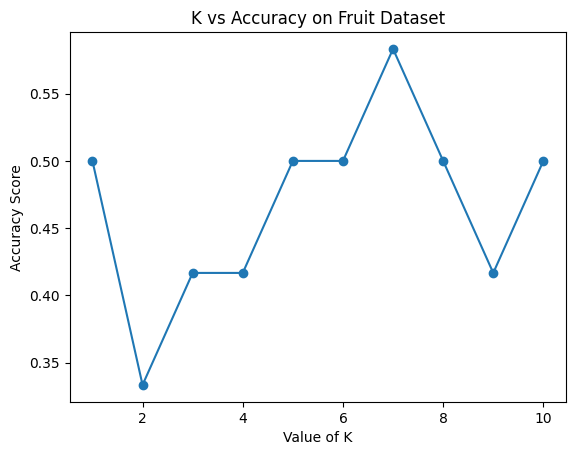

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Load data
df = pd.read_csv("Untitled Folder/fruit_data_with_colors.csv")

# 2. Prepare data
df = df.drop(columns=['fruit_name', 'fruit_subtype'])
df = df.fillna(df.mean())

# 3. Proper random split
X = df.drop('fruit_label', axis=1)
y = df['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4 & 5. Loop through K values
k_values = range(1, 11)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

# 6. Plot
plt.plot(k_values, scores, marker='o')
plt.xlabel("Value of K")
plt.ylabel("Accuracy Score")
plt.title("K vs Accuracy on Fruit Dataset")
plt.show()

# Reflection